# Agentic Rag with ReAct Architecture

In [60]:
import os
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,START,END
from typing import Annotated,Sequence,TypedDict
from pydantic import BaseModel
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model

Loading Docs from webpage

In [61]:
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks = splitter.split_documents(docs)

Retriever and Vectorstore setup

In [62]:
embedding = HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks,embedding)
retriever = vectorstore.as_retriever()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

# Tools setup

Retriever Tool

In [63]:
@tool
def retriever_tool_fnc(query:str) -> str:
    """Use this tool to fetch relevant knowlege base info from indexed documents"""
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

Wikipedia tool

In [64]:
import wikipediaapi
import wikipedia
wiki = wikipediaapi.Wikipedia(
    language="en",
    user_agent = "pappu"
)

@tool
def search_wikipedia(query:str) -> str:
    """"Seach wikipedia for a query and returns best matching article"""
    try:
        results=wikipedia.search(query)
        if not results:
            return "No matching Wikipedia articles found."
        
        page = wiki.page(results[0])

        return f"""
Title: {page.title}
Summary:
{page.summary[:500]}
URL:
{page.fullurl}
"""
    except Exception as e:
        return str(e)

In [65]:
tools = [retriever_tool_fnc,search_wikipedia]

building the main node / Langgraph ReACT Agent

In [66]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002624BC87770>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002624BC85DF0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [67]:
react_agent = create_agent(
    model=llm,
    tools=tools
)

Building the StateGraph

In [68]:
class AgentState(BaseModel):
    messages: Annotated[Sequence[BaseMessage],add_messages]

In [69]:
def react_node(state: AgentState):
    result = react_agent.invoke({"messages": state.messages})
    return {"messages": result["messages"]}

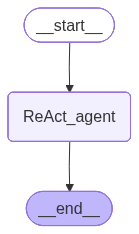

In [70]:
builder = StateGraph(AgentState)
builder.add_node("ReAct_agent",react_node)
builder.set_entry_point("ReAct_agent")
builder.add_edge("ReAct_agent",END)
graph = builder.compile()
graph

invoking the agentic rag